# Sentiment Analysis using RNN, LSTM, Bi-directional LSTM, and GRU

This notebook implements sentiment analysis on the IMDB movie reviews dataset using different types of recurrent neural networks.

We use:
- Embedding layer
- Simple RNN
- LSTM
- Bidirectional LSTM
- GRU


In [ ]:
# Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense

In [ ]:
# Load and preprocess dataset
vocab_size = 10000
maxlen = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Function to compile and train model
def compile_and_train(model, name):
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    print(f"Training {name}...")
    model.fit(X_train, y_train, epochs=3, batch_size=128, validation_data=(X_test, y_test))
    print(f"Evaluating {name}...")
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Accuracy: {acc:.4f}")

## RNN Model

In [ ]:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
compile_and_train(rnn_model, "RNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6674 - loss: 0.5843 - val_accuracy: 0.8290 - val_loss: 0.4011
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8277 - loss: 0.3953 - val_accuracy: 0.8200 - val_loss: 0.4175
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9046 - loss: 0.2425 - val_accuracy: 0.8124 - val_loss: 0.4657
Evaluating RNN...
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8124 - loss: 0.4657
RNN Accuracy: 0.8124


## LSTM Model

In [ ]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
compile_and_train(lstm_model, "LSTM")

Training LSTM...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8020 - loss: 0.4120 - val_accuracy: 0.8691 - val_loss: 0.3053
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9063 - loss: 0.2384 - val_accuracy: 0.8544 - val_loss: 0.3409
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9310 - loss: 0.1833 - val_accuracy: 0.8654 - val_loss: 0.3482
Evaluating LSTM...
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8654 - loss: 0.3482
LSTM Accuracy: 0.8654


## Bi-directional LSTM Model

In [ ]:
bilstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])
compile_and_train(bilstm_model, "Bi-directional LSTM")

Training Bi-directional LSTM...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7541 - loss: 0.4864 - val_accuracy: 0.8488 - val_loss: 0.3623
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8925 - loss: 0.2739 - val_accuracy: 0.8507 - val_loss: 0.3435
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9204 - loss: 0.2072 - val_accuracy: 0.8611 - val_loss: 0.3394
Evaluating Bi-directional LSTM...
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8611 - loss: 0.3394
Bi-directional LSTM Accuracy: 0.8611


## GRU Model

In [ ]:
gru_model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    GRU(64),
    Dense(1, activation='sigmoid')
])
compile_and_train(gru_model, "GRU")

Training GRU...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7780 - loss: 0.4476 - val_accuracy: 0.8298 - val_loss: 0.3849
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8963 - loss: 0.2579 - val_accuracy: 0.8647 - val_loss: 0.3261
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9292 - loss: 0.1903 - val_accuracy: 0.8671 - val_loss: 0.3187
Evaluating GRU...
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8671 - loss: 0.3187
GRU Accuracy: 0.8671


**Plots for training/validation accuracy and loss with ROC**

Training RNN...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.7059 - loss: 0.5380 - val_accuracy: 0.8459 - val_loss: 0.3597
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8568 - loss: 0.3333 - val_accuracy: 0.8296 - val_loss: 0.4092
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9187 - loss: 0.2102 - val_accuracy: 0.8518 - val_loss: 0.4027


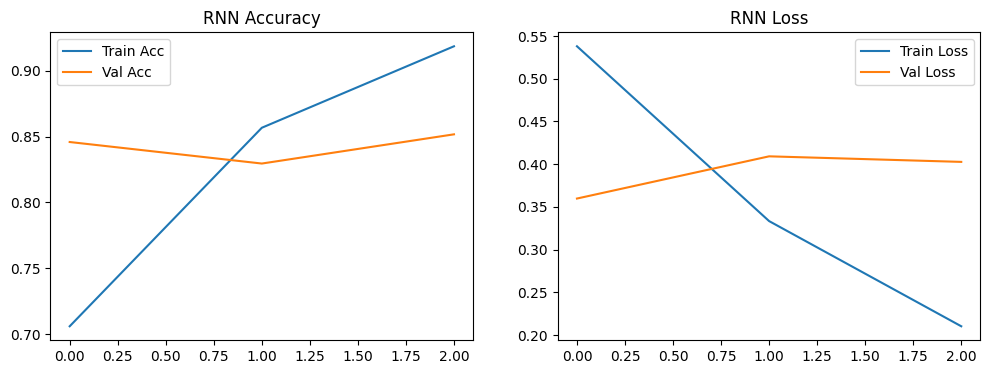

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8518 - loss: 0.4027
RNN Test Accuracy: 0.8518
Training LSTM...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7928 - loss: 0.4364 - val_accuracy: 0.8658 - val_loss: 0.3210
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9017 - loss: 0.2521 - val_accuracy: 0.8700 - val_loss: 0.3155
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9310 - loss: 0.1809 - val_accuracy: 0.8671 - val_loss: 0.3416


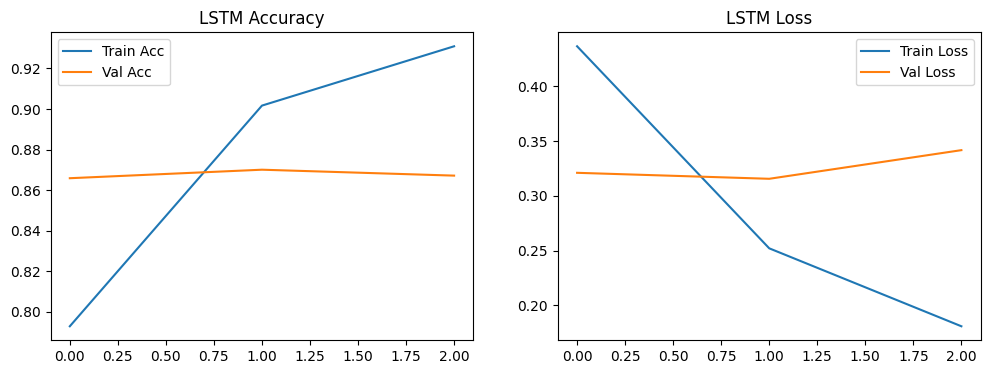

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8671 - loss: 0.3416
LSTM Test Accuracy: 0.8671
Training BiLSTM...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7862 - loss: 0.4435 - val_accuracy: 0.8648 - val_loss: 0.3221
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9062 - loss: 0.2416 - val_accuracy: 0.8706 - val_loss: 0.3148
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9268 - loss: 0.1965 - val_accuracy: 0.8659 - val_loss: 0.3552


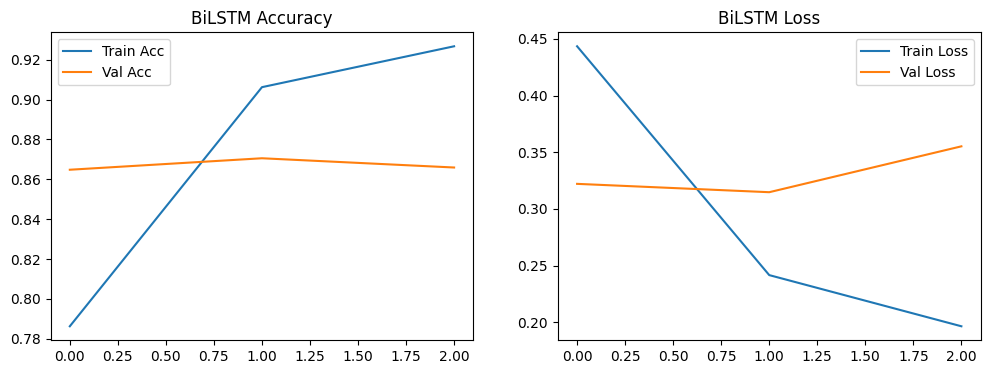

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8659 - loss: 0.3552
BiLSTM Test Accuracy: 0.8659
Training GRU...
Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7115 - loss: 0.5471 - val_accuracy: 0.8378 - val_loss: 0.3768
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8819 - loss: 0.2846 - val_accuracy: 0.8653 - val_loss: 0.3251
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9243 - loss: 0.2002 - val_accuracy: 0.8612 - val_loss: 0.3359


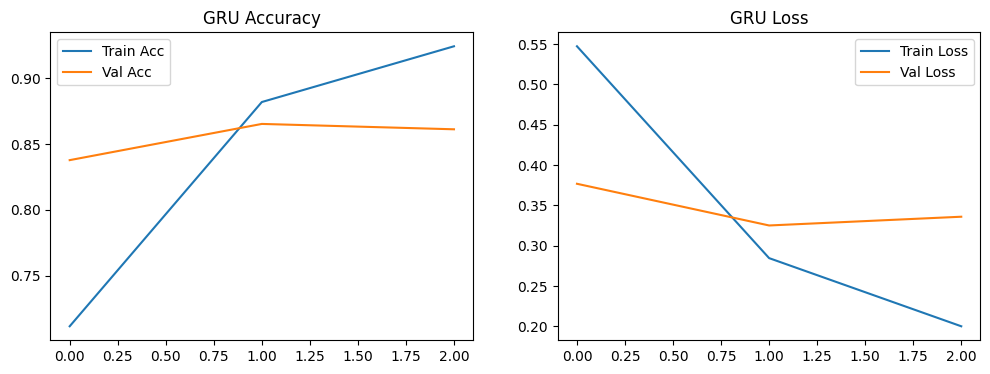

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8612 - loss: 0.3359
GRU Test Accuracy: 0.8612


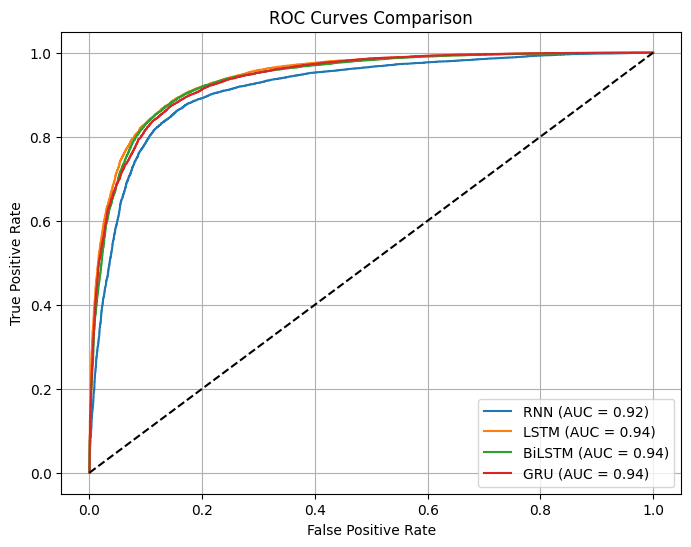

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense

# Load and preprocess IMDB dataset
vocab_size = 10000
maxlen = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Function to compile, train, evaluate with plots and ROC
def compile_train_roc(model, name, model_preds):
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    print(f"Training {name}...")
    history = model.fit(X_train, y_train, epochs=3, batch_size=128, validation_data=(X_test, y_test))

    # Accuracy and Loss plots
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    # Predictions and ROC
    y_pred_prob = model.predict(X_test)
    model_preds[name] = y_pred_prob
    loss, acc = model.evaluate(X_test, y_test)
    print(f"{name} Test Accuracy: {acc:.4f}")

# Train all models and collect predictions
model_predictions = {}

# RNN
rnn = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
compile_train_roc(rnn, "RNN", model_predictions)

# LSTM
lstm = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
compile_train_roc(lstm, "LSTM", model_predictions)

# Bi-directional LSTM
bilstm = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])
compile_train_roc(bilstm, "BiLSTM", model_predictions)

# GRU
gru = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    GRU(64),
    Dense(1, activation='sigmoid')
])
compile_train_roc(gru, "GRU", model_predictions)

# Plot ROC curves
plt.figure(figsize=(8, 6))
for name, y_pred in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()
